In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)

In [2]:
ped = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/data/pedestrians.csv')
ped.head()

,timestamp,locationuid,direction,speed,count
0,2018-11-01 08:00:00,004361eb,165,2.641,1
1,2018-11-01 09:15:00,004361eb,165,2.641,1
2,2018-11-01 11:45:00,004361eb,165,2.641,1
3,2018-11-01 11:45:00,004361eb,345,2.641,1
4,2018-11-01 12:45:00,004361eb,165,2.641,1


In [3]:
print("Total rows:", len(ped))
print("\nMissing:")
print(ped.isnull().sum())
print("\nDuplicates:", ped.duplicated().sum())
print("\nSummary:")
ped.describe()

Total rows: 31502953

Missing:
timestamp      0
locationuid    0
direction      0
speed          0
count          0
dtype: int64

Duplicates: 0

Summary:


,direction,speed,count
count,3.150295e+07,3.150295e+07,3.150295e+07
mean,1.834278e+02,2.026961e+00,4.593354e+00
std,1.094149e+02,8.857956e-01,8.388960e+00
min,-1.000000e+00,0.000000e+00,1.000000e+00
25%,9.000000e+01,1.494250e+00,1.000000e+00
50%,1.800000e+02,2.247167e+00,2.000000e+00
75%,2.700000e+02,2.641000e+00,5.000000e+00
max,3.600000e+02,1.492023e+02,1.190000e+03


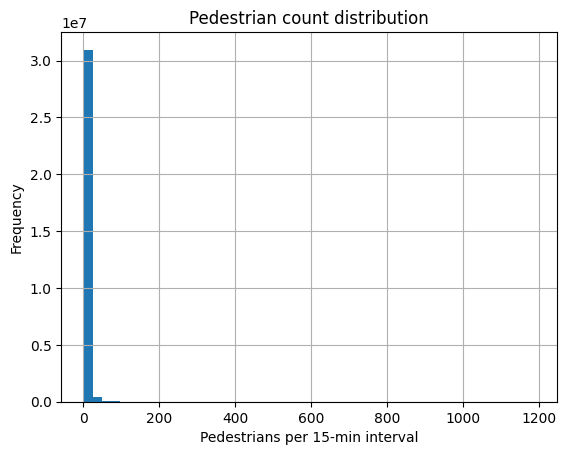

In [4]:
ped['count'].hist(bins=50)
plt.title('Pedestrian count distribution')
plt.xlabel('Pedestrians per 15-min interval')
plt.ylabel('Frequency')
plt.show()

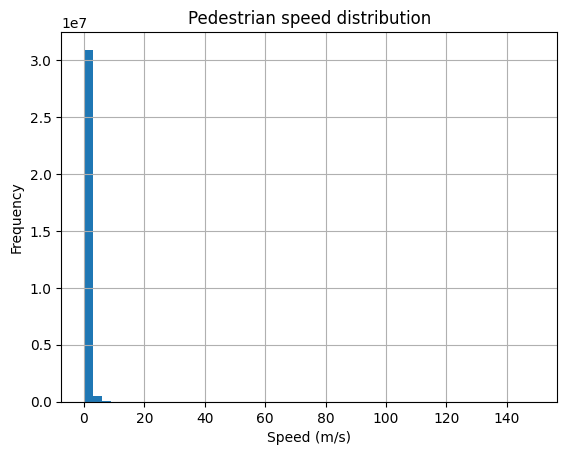

In [5]:
ped['speed'].hist(bins=50)
plt.title('Pedestrian speed distribution')
plt.xlabel('Speed (m/s)')
plt.ylabel('Frequency')
plt.show()

In [6]:
print("Rows with direction = -1:", (ped['direction'] == -1).sum())
print("Rows with speed > 10 m/s (faster than running):", (ped['speed'] > 10).sum())
print("Rows with count > 100 pedestrians:", (ped['count'] > 100).sum())

Rows with direction = -1: 30657
Rows with speed > 10 m/s (faster than running): 17949
Rows with count > 100 pedestrians: 33132


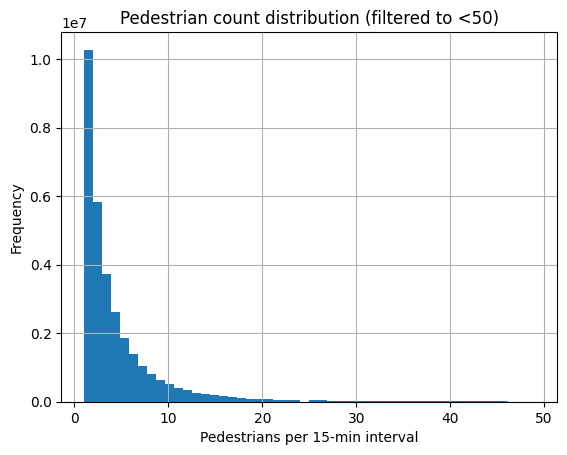

In [7]:
# Filter out the extreme outliers for a cleaner view
ped[ped['count'] < 50]['count'].hist(bins=50)
plt.title('Pedestrian count distribution (filtered to <50)')
plt.xlabel('Pedestrians per 15-min interval')
plt.ylabel('Frequency')
plt.show()

In [8]:
print("--- Pedestrian Count Distribution ---")
print(ped['count'].describe())
print(f"\nSkewness: {ped['count'].skew():.2f}  (>1 = heavily right-skewed)")
print(f"% of rows with count == 1:  {(ped['count']==1).mean()*100:.1f}%")
print(f"% of rows with count <= 2:  {(ped['count']<=2).mean()*100:.1f}%")

print("\n--- Anomaly Flags ---")
print(f"Rows with direction == -1 (invalid):           {(ped['direction']==-1).sum():,}")
print(f"Rows with speed > 10 m/s (impossible walking): {(ped['speed']>10).sum():,}")
print(f"Rows with count > 100 (likely event days):     {(ped['count']>100).sum():,}")
total = len(ped)
flagged = ((ped['direction']==-1) | (ped['speed']>10) | (ped['count']>100)).sum()
print(f"Total flagged rows: {flagged:,} ({flagged/total*100:.2f}% of data)")

print("\n--- Walking Speed Distribution (after filtering >10 m/s outliers) ---")
normal_speeds = ped[ped['speed'] <= 10]['speed']
print(normal_speeds.describe())

print("\n--- Temporal Coverage ---")
print(f"Earliest timestamp: {ped['timestamp'].min()}")
print(f"Latest timestamp:   {ped['timestamp'].max()}")
print(f"Unique sensor locations: {ped['locationuid'].nunique():,}")

--- Pedestrian Count Distribution ---
count    3.150295e+07
mean     4.593354e+00
std      8.388960e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      1.190000e+03
Name: count, dtype: float64

Skewness: 14.61  (>1 = heavily right-skewed)
% of rows with count == 1:  32.6%
% of rows with count <= 2:  51.2%

--- Anomaly Flags ---
Rows with direction == -1 (invalid):           30,657
Rows with speed > 10 m/s (impossible walking): 17,949
Rows with count > 100 (likely event days):     33,132
Total flagged rows: 81,666 (0.26% of data)

--- Walking Speed Distribution (after filtering >10 m/s outliers) ---
count    3.148500e+07
mean     2.019612e+00
std      8.153096e-01
min      0.000000e+00
25%      1.492351e+00
50%      2.244834e+00
75%      2.641000e+00
max      9.999964e+00
Name: speed, dtype: float64

--- Temporal Coverage ---
Earliest timestamp: 2018-08-01 06:45:00
Latest timestamp:   2019-06-01 00:00:00
Unique sensor locations: 2,691


## CityIQ Pedestrian Data (Aug 2018 – Jun 2019)

**Datasets explored**
- pedestrians.csv: 31,502,953 rows x 5 cols - 15-min interval pedestrian counts per sensor
- segments.csv: 11,269 rows - street segment metadata for sensor locations
- 2,691 unique sensor locations covering ~10 months of data

**Data quality**
- 0 missing values across all columns
- 0.26% of rows flagged as anomalies (81,666 of 31.5M)
  - 30,657 rows with direction = -1 (sensor calibration errors)
  - 17,949 rows with speed > 10 m/s (impossible walking pace)
  - 33,132 rows with count > 100 (likely event days)
- Walking speeds cluster around 2.02 m/s (matches normal walking pace)

**Distributions**
- Pedestrian counts extremely right-skewed (skewness = 14.61)
- 32.6% of rows have count = 1
- 51.2% of rows have count <= 2
- Mean 4.6, median 2, max 1,190

**Next steps**
- Filter or flag the 81,666 anomaly rows before clustering
- Aggregate counts to daily/hourly per locationuid
- Spatial join sensor locations with census tracts